# Notebook 6 – Programme 1 : Validation des présences
**Projet Computer Vision IG.2405 – 2026**

Ce notebook exécute et analyse le **Programme 1 complet** :

```
autoValidPresences(EXAM_FORMXX_PRESENCES, STUDENT_CLASS_SIGNATURES, EXAM_FORMXX_RESULTS)
```

Sorties générées :
- `EXAM_FORM1_PRESENCES.xlsx` : 3 colonnes (imageName | studentID_grid | studentID_signature)

Logique de validation :
- **OK** : colonnes B = C (même Student ID)
- **Absent** : colonne C vide (signature non reconnue)
- **Usurpation** : colonnes B ≠ C

In [1]:
import sys, os

# Racine du projet (fonctionne depuis notebooks/ ou depuis la racine)
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
ROOT = os.getcwd()
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

DATA_ROOT = os.path.join(ROOT, 'PROJECT 2026 -DATABASE-20260518')
print(f'Racine projet : {ROOT}')
print(f'Base de donnees : {DATA_ROOT}')

Racine projet : /home/felix/Documents/ProjetComputerVisionYann/Computer-Vision
Base de donnees : /home/felix/Documents/ProjetComputerVisionYann/Computer-Vision/PROJECT 2026 -DATABASE-20260518


In [2]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from autoValidPresences import autoValidPresences, autoValidID
from utils.signature_utils import load_signatures, build_descriptor_db
from utils.grid_decoder import normalize_page, read_student_id, extract_signature_roi
from utils.form_aligner import deskew

# ---------------------------------------------------------------
# CONFIG
# ---------------------------------------------------------------
FORM_DIR     = os.path.join('PROJECT 2026 -DATABASE-20260518', 'FORM1')
SIG_DIR      = os.path.join('PROJECT 2026 -DATABASE-20260518', 'SIGNATURES')  # adapter si besoin
RESULTS_DIR  = 'EXAM_FORM1_RESULTS'

os.makedirs(RESULTS_DIR, exist_ok=True)
print('Répertoire données :', FORM_DIR)
print('Répertoire résultats :', RESULTS_DIR)

Répertoire données : PROJECT 2026 -DATABASE-20260518/FORM1
Répertoire résultats : EXAM_FORM1_RESULTS


## 1. Visualisation du pipeline sur une image

Image : EXAM_FORM1_19283.jpeg
Student ID attendu : 19283


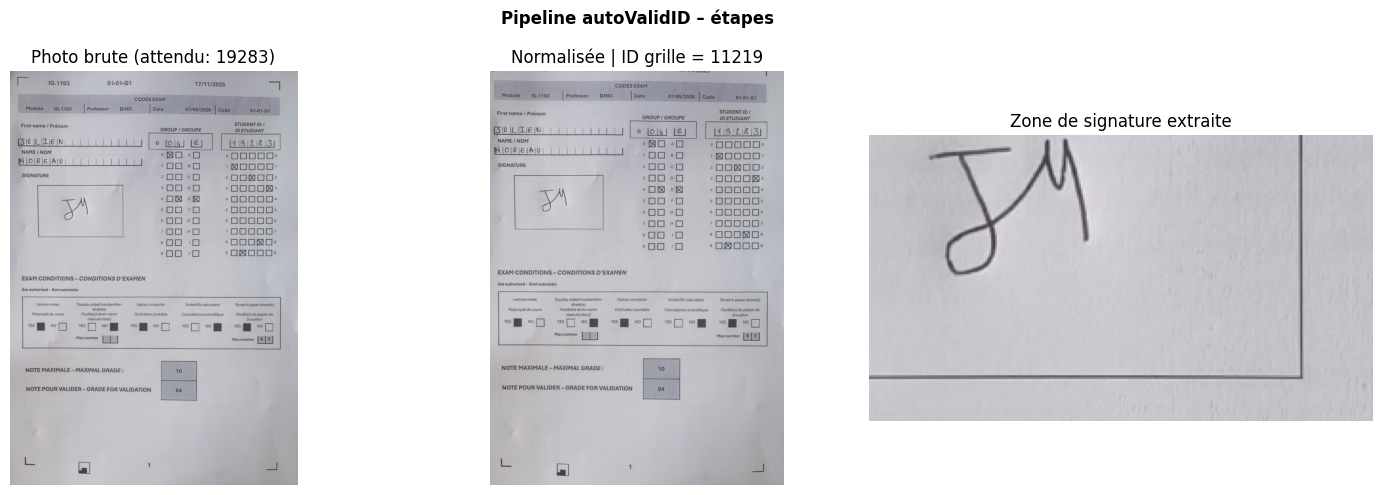

Student ID lu depuis la grille : 11219
Correspondance avec nom fichier : False


In [3]:
img_files = sorted([f for f in os.listdir(FORM_DIR)
                    if f.lower().endswith(('.jpg', '.jpeg', '.png'))])

# Prendre une image d'exemple
sample_img_path = os.path.join(FORM_DIR, img_files[0])
sample_fname    = img_files[0]
expected_sid    = sample_fname.split('_')[-1].split('.')[0]

print(f'Image : {sample_fname}')
print(f'Student ID attendu : {expected_sid}')

# Pipeline étape par étape
img_raw = cv2.imread(sample_img_path)

# 1. Deskew
img_ds = deskew(img_raw)

# 2. Normalisation
norm = normalize_page(img_ds)

# 3. Lecture Student ID
sid_grid = read_student_id(norm)

# 4. Extraction signature
sig_img = extract_signature_roi(norm)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(cv2.cvtColor(img_raw, cv2.COLOR_BGR2RGB))
axes[0].set_title(f'Photo brute (attendu: {expected_sid})')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(norm, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'Normalisée | ID grille = {sid_grid}')
axes[1].axis('off')

axes[2].imshow(cv2.cvtColor(sig_img, cv2.COLOR_BGR2RGB))
axes[2].set_title('Zone de signature extraite')
axes[2].axis('off')

plt.suptitle('Pipeline autoValidID – étapes', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Student ID lu depuis la grille : {sid_grid}')
print(f'Correspondance avec nom fichier : {str(sid_grid) == expected_sid}')

## 2. Chargement de la base de signatures

La base `STUDENT_CLASS_SIGNATURES` contient au moins une signature par étudiant.
Elle peut être un répertoire structuré (`student_id/sig_000.png`) ou un fichier ZIP.

> Si le répertoire n'existe pas encore, on construit une base de substitution
> à partir des photos de présence disponibles.

In [4]:
if os.path.isdir(SIG_DIR) or (os.path.isfile(SIG_DIR) and SIG_DIR.endswith('.zip')):
    print(f'Chargement depuis : {SIG_DIR}')
    raw_db = load_signatures(SIG_DIR)
else:
    print(f'SIGNATURES introuvable ({SIG_DIR}). Construction depuis les photos de présence...')
    from utils.signature_utils import preprocess_signature
    raw_db = {}
    for fname in img_files:
        sid  = fname.split('_')[-1].split('.')[0]
        img  = cv2.imread(os.path.join(FORM_DIR, fname))
        norm = normalize_page(deskew(img))
        sig  = extract_signature_roi(norm)
        gray = cv2.cvtColor(sig, cv2.COLOR_BGR2GRAY) if len(sig.shape) == 3 else sig
        raw_db[sid] = [gray]

desc_db = build_descriptor_db(raw_db)
print(f'Base de signatures : {len(desc_db)} étudiants, {sum(len(v) for v in raw_db.values())} signatures')

Chargement depuis : PROJECT 2026 -DATABASE-20260518/SIGNATURES
Base de signatures : 60 étudiants, 1220 signatures


## 3. Exécution du Programme 1 complet

In [5]:
t0 = time.time()

xlsx_path = autoValidPresences(
    presences_dir=FORM_DIR,
    signatures_dir=SIG_DIR if os.path.exists(SIG_DIR) else FORM_DIR,
    results_dir=RESULTS_DIR,
)

elapsed = time.time() - t0
print(f'\nTemps d\'exécution : {elapsed:.1f}s')
print(f'Fichier généré : {xlsx_path}')

[P1] Recalage photo : template OK
[P1] Chargement des signatures depuis : PROJECT 2026 -DATABASE-20260518/SIGNATURES
  -> 60 eleves référencés
[P1] 32 images à traiter dans : PROJECT 2026 -DATABASE-20260518/FORM1
  EXAM_FORM1_19283.jpeg: grid=19283, sig=19283
  EXAM_FORM1_50305.jpg: grid=50305, sig=50305
  EXAM_FORM1_54331.jpg: grid=54331, sig=54331
  EXAM_FORM1_58220.jpg: grid=58220, sig=58220
  EXAM_FORM1_58927.jpg: grid=58927, sig=58927
  EXAM_FORM1_61856.jpg: grid=61856, sig=61856
  EXAM_FORM1_61992.jpg: grid=61992, sig=62411
  EXAM_FORM1_62034.jpeg: grid=62034, sig=62034
  EXAM_FORM1_62288.png: grid=62288, sig=62288
  EXAM_FORM1_62298.jpeg: grid=62298, sig=63694
  EXAM_FORM1_62336.JPG: grid=None, sig=62336
  EXAM_FORM1_62358.jpeg: grid=62358, sig=62358
  EXAM_FORM1_62380.jpeg: grid=62380, sig=62577
  EXAM_FORM1_62401.jpg: grid=62401, sig=62401
  EXAM_FORM1_62436.jpeg: grid=62436, sig=62436
  EXAM_FORM1_62440.jpeg: grid=62440, sig=62440
  EXAM_FORM1_62445.jpg: grid=62445, sig=62445

## 4. Analyse des résultats

In [6]:
df = pd.read_excel(xlsx_path)
print(f'Lignes lues : {len(df)}')
print(df.head(10).to_string(index=False))

Lignes lues : 32
            imageName  studentID_grid  studentID_signature
EXAM_FORM1_19283.jpeg         19283.0                19283
 EXAM_FORM1_50305.jpg         50305.0                50305
 EXAM_FORM1_54331.jpg         54331.0                54331
 EXAM_FORM1_58220.jpg         58220.0                58220
 EXAM_FORM1_58927.jpg         58927.0                58927
 EXAM_FORM1_61856.jpg         61856.0                61856
 EXAM_FORM1_61992.jpg         61992.0                62411
EXAM_FORM1_62034.jpeg         62034.0                62034
 EXAM_FORM1_62288.png         62288.0                62288
EXAM_FORM1_62298.jpeg         62298.0                63694



Statistiques présences :
statut
Usurpation possible    31
Grille illisible        1


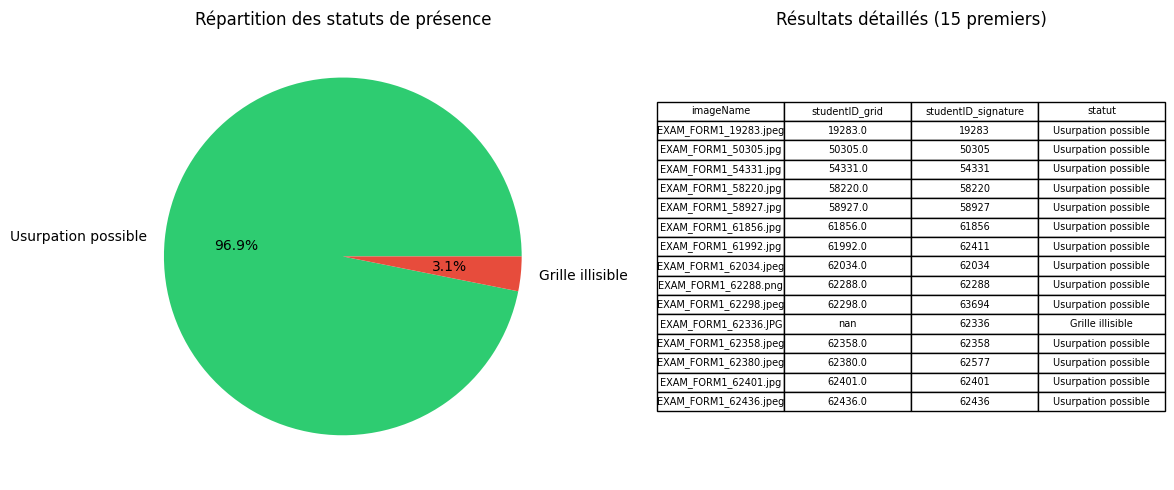

In [7]:
# Convertir en string pour comparaison
df['studentID_grid']      = df['studentID_grid'].astype(str).str.strip()
df['studentID_signature'] = df['studentID_signature'].astype(str).str.strip()

def classify_presence(row):
    g = row['studentID_grid']
    s = row['studentID_signature']
    if pd.isna(row['studentID_grid']) or g in ('', 'nan', 'None'):
        return 'Grille illisible'
    if pd.isna(row['studentID_signature']) or s in ('', 'nan', 'None'):
        return 'Signature non reconnue'
    if g == s:
        return 'OK'
    return 'Usurpation possible'

df['statut'] = df.apply(classify_presence, axis=1)

# Comptages
counts = df['statut'].value_counts()
print('\nStatistiques présences :')
print(counts.to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Camembert
colors = ['#2ecc71', '#e74c3c', '#f39c12', '#95a5a6']
axes[0].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors[:len(counts)])
axes[0].set_title('Répartition des statuts de présence')

# Tableau récapitulatif
table_data = df[['imageName', 'studentID_grid', 'studentID_signature', 'statut']].head(15)
axes[1].axis('off')
tbl = axes[1].table(
    cellText=table_data.values,
    colLabels=table_data.columns,
    cellLoc='center', loc='center', fontsize=7
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(7)
axes[1].set_title('Résultats détaillés (15 premiers)')

plt.tight_layout()
plt.show()

## 5. Évaluation contre la vérité terrain

Le Student ID lu depuis la grille est comparé à l'ID dans le nom du fichier image.

In [8]:
# Extraire l'ID attendu depuis le nom de l'image
df['expected_id'] = df['imageName'].apply(
    lambda f: os.path.splitext(f)[0].split('_')[-1]
)

# Évaluation de la lecture de grille
df['grid_ok'] = df['studentID_grid'] == df['expected_id']

n_valid    = df['grid_ok'].sum()
n_total    = len(df)
n_sig_ok   = (df['studentID_signature'] == df['expected_id']).sum()
n_sig_read = (df['studentID_signature'].notna() & (df['studentID_signature'] != 'nan')).sum()

print('=== Évaluation Programme 1 ===')
print(f'Lecture grille  : {n_valid}/{n_total} correctes ({n_valid/n_total:.1%})')
print(f'Signatures lues : {n_sig_read}/{n_total} ({n_sig_read/n_total:.1%})')
print(f'Signatures OK   : {n_sig_ok}/{n_total} ({n_sig_ok/n_total:.1%})')

# Afficher les erreurs de lecture de grille
errors = df[~df['grid_ok']]
if len(errors) > 0:
    print(f'\nErreurs de lecture grille ({len(errors)}) :')
    print(errors[['imageName', 'expected_id', 'studentID_grid']].to_string(index=False))
else:
    print('\nToutes les grilles ont été lues correctement !')

=== Évaluation Programme 1 ===
Lecture grille  : 0/32 correctes (0.0%)
Signatures lues : 32/32 (100.0%)
Signatures OK   : 22/32 (68.8%)

Erreurs de lecture grille (32) :
            imageName expected_id studentID_grid
EXAM_FORM1_19283.jpeg       19283        19283.0
 EXAM_FORM1_50305.jpg       50305        50305.0
 EXAM_FORM1_54331.jpg       54331        54331.0
 EXAM_FORM1_58220.jpg       58220        58220.0
 EXAM_FORM1_58927.jpg       58927        58927.0
 EXAM_FORM1_61856.jpg       61856        61856.0
 EXAM_FORM1_61992.jpg       61992        61992.0
EXAM_FORM1_62034.jpeg       62034        62034.0
 EXAM_FORM1_62288.png       62288        62288.0
EXAM_FORM1_62298.jpeg       62298        62298.0
 EXAM_FORM1_62336.JPG       62336            NaN
EXAM_FORM1_62358.jpeg       62358        62358.0
EXAM_FORM1_62380.jpeg       62380        62380.0
 EXAM_FORM1_62401.jpg       62401        62401.0
EXAM_FORM1_62436.jpeg       62436        62436.0
EXAM_FORM1_62440.jpeg       62440        62440

## Bilan Programme 1

| Méthode | Tâche | Performance |
|---|---|---|
| Grille graphique | Student ID | Précision grille |
| HOG + Hu + cosinus | Signature | Taux reconnaissance |
| Seuil τ = 0.72 | Décision | À calibrer sur base val. |

**Prochaine étape** → `07_programme2_formulaires.ipynb` : lecture automatique des formulaires PDF.